<a href="https://colab.research.google.com/github/LakshyaTyagi15/Data-Science/blob/main/Alzheimer_Disease/Alzheimer_Disease.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
%%writefile fetch_oasis.cpp
#include <cstdlib>
#include <fstream>
#include <string>

using namespace std;

int main() {
    system("mkdir -p ~/.kaggle");

    ofstream file(string(getenv("HOME")) + "/.kaggle/kaggle.json");
    file << R"({"username":"lakshyatyagi06","key":"421d4dae9d78d0298af87c7f49b5fe9d"})";
    file.close();

    system("chmod 600 ~/.kaggle/kaggle.json");
    system("kaggle datasets download -d ninadaithal/imagesoasis");
    system("mkdir -p /content/OasisData");
    system("unzip -q -o imagesoasis.zip -d /content/OasisData/");
    system("ls -lh /content/OasisData/Data");

    return 0;
}

Writing fetch_oasis.cpp


In [ ]:
!g++ fetch_oasis.cpp -o fetch_oasis && ./fetch_oasis

Dataset URL: https://www.kaggle.com/datasets/ninadaithal/imagesoasis
License(s): apache-2.0
100% 1.23G/1.23G [00:56<00:00, 23.5MB/s]

total 4.4M
drwxr-xr-x 2 root root 256K Mar 17 17:13 'Mild Dementia'
drwxr-xr-x 2 root root  32K Mar 17 17:13 'Moderate Dementia'
drwxr-xr-x 2 root root 3.4M Mar 17 17:13 'Non Demented'
drwxr-xr-x 2 root root 692K Mar 17 17:14 'Very mild Dementia'


In [ ]:
!mkdir -p ~/.kaggle
!echo '{"username":"lakshyatyagi06","key":"421d4dae9d78d0298af87c7f49b5fe9d"}' > ~/.kaggle/kaggle.json
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d ninadaithal/imagesoasis
!unzip -q -o imagesoasis.zip -d /content/OasisData/

Dataset URL: https://www.kaggle.com/datasets/ninadaithal/imagesoasis
License(s): apache-2.0
100% 1.23G/1.23G [00:11<00:00, 112MB/s]



In [ ]:
import torch
import torchvision.models as models
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader
from sklearn.decomposition import PCA
import numpy as np
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

dataset = datasets.ImageFolder(root='/content/OasisData/Data', transform=transform)
dataloader = DataLoader(dataset, batch_size=64, shuffle=False, num_workers=2)

model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
model.fc = torch.nn.Identity()
model = model.to(device)
model.eval()

all_features = []
all_labels = []

with torch.no_grad():
    for images, targets in tqdm(dataloader):
        images = images.to(device)
        outputs = model(images)
        all_features.append(outputs.cpu().numpy())
        all_labels.append(targets.numpy())

features_matrix = np.vstack(all_features)
labels_vector = np.concatenate(all_labels)

pca = PCA(n_components=128)
reduced_features = pca.fit_transform(features_matrix)

print(reduced_features.shape)
print(labels_vector.shape)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 185MB/s]
100%|██████████| 1351/1351 [04:33<00:00,  4.95it/s]


(86437, 128)
(86437,)


In [ ]:
!pip install torch_geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 33.2 MB/s eta 0:00:00


In [ ]:
!pip install scikit-learn
from sklearn.neighbors import NearestNeighbors
from sklearn.model_selection import train_test_split
import torch
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

nbrs = NearestNeighbors(n_neighbors=5, algorithm='auto').fit(reduced_features)
distances, indices = nbrs.kneighbors(reduced_features)

source_nodes = np.repeat(np.arange(indices.shape[0]), indices.shape[1])
target_nodes = indices.flatten()
edge_index = torch.tensor([source_nodes, target_nodes], dtype=torch.long)

x = torch.tensor(reduced_features, dtype=torch.float)
y = torch.tensor(labels_vector, dtype=torch.long)

train_idx, test_idx = train_test_split(range(len(y)), test_size=0.2, random_state=42)
train_mask = torch.zeros(len(y), dtype=torch.bool)
test_mask = torch.zeros(len(y), dtype=torch.bool)
train_mask[train_idx] = True
test_mask[test_idx] = True

data = Data(x=x, edge_index=edge_index, y=y, train_mask=train_mask, test_mask=test_mask).to(device)

class GCN(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = GCNConv(128, 64)
        self.conv2 = GCNConv(64, 4)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.conv2(x, edge_index)
        return F.log_softmax(x, dim=1)

model = GCN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)

model.train()
for epoch in range(200):
    optimizer.zero_grad()
    out = model(data)
    loss = F.nll_loss(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()

model.eval()
pred = model(data).argmax(dim=1)
correct = (pred[data.test_mask] == data.y[data.test_mask]).sum()
acc = int(correct) / int(data.test_mask.sum())
print(acc)

ModuleNotFoundError: No module named 'torch_geometric'

              precision    recall  f1-score   support

           0       0.98      0.96      0.97       954
           1       1.00      0.59      0.74        98
           2       0.99      1.00      0.99     13527
           3       0.98      0.95      0.96      2709

    accuracy                           0.98     17288
   macro avg       0.99      0.87      0.92     17288
weighted avg       0.98      0.98      0.98     17288



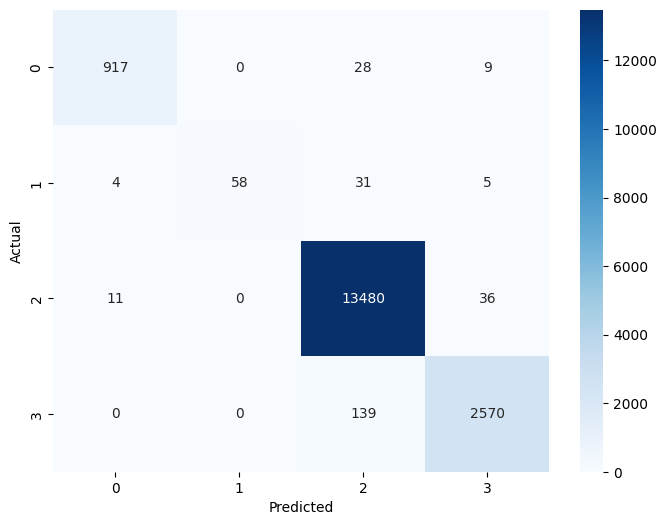

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

model.eval()
out = model(data)
pred = out.argmax(dim=1).cpu().numpy()
true_labels = data.y.cpu().numpy()
test_mask = data.test_mask.cpu().numpy()

test_true = true_labels[test_mask]
test_pred = pred[test_mask]

print(classification_report(test_true, test_pred))

cm = confusion_matrix(test_true, test_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()